In [ ]:
import torch
words=open('names.txt','r').read().splitlines()

# Bigram by storing the number of occurrence of each pair

In [64]:
N=torch.zeros(27,27)
stoi={'.':0}
stoi={ch:i+1 for i,ch in enumerate(list("abcdefghijklmnopqrstuvwxyz"))}
stoi['.']=0
itos={i:ch for ch,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [65]:
for w in words:
    chs=['.']+list(w)+['.']
    for c1,c2 in zip(chs[:],chs[1:]):
        N[stoi[c1],stoi[c2]]+=1

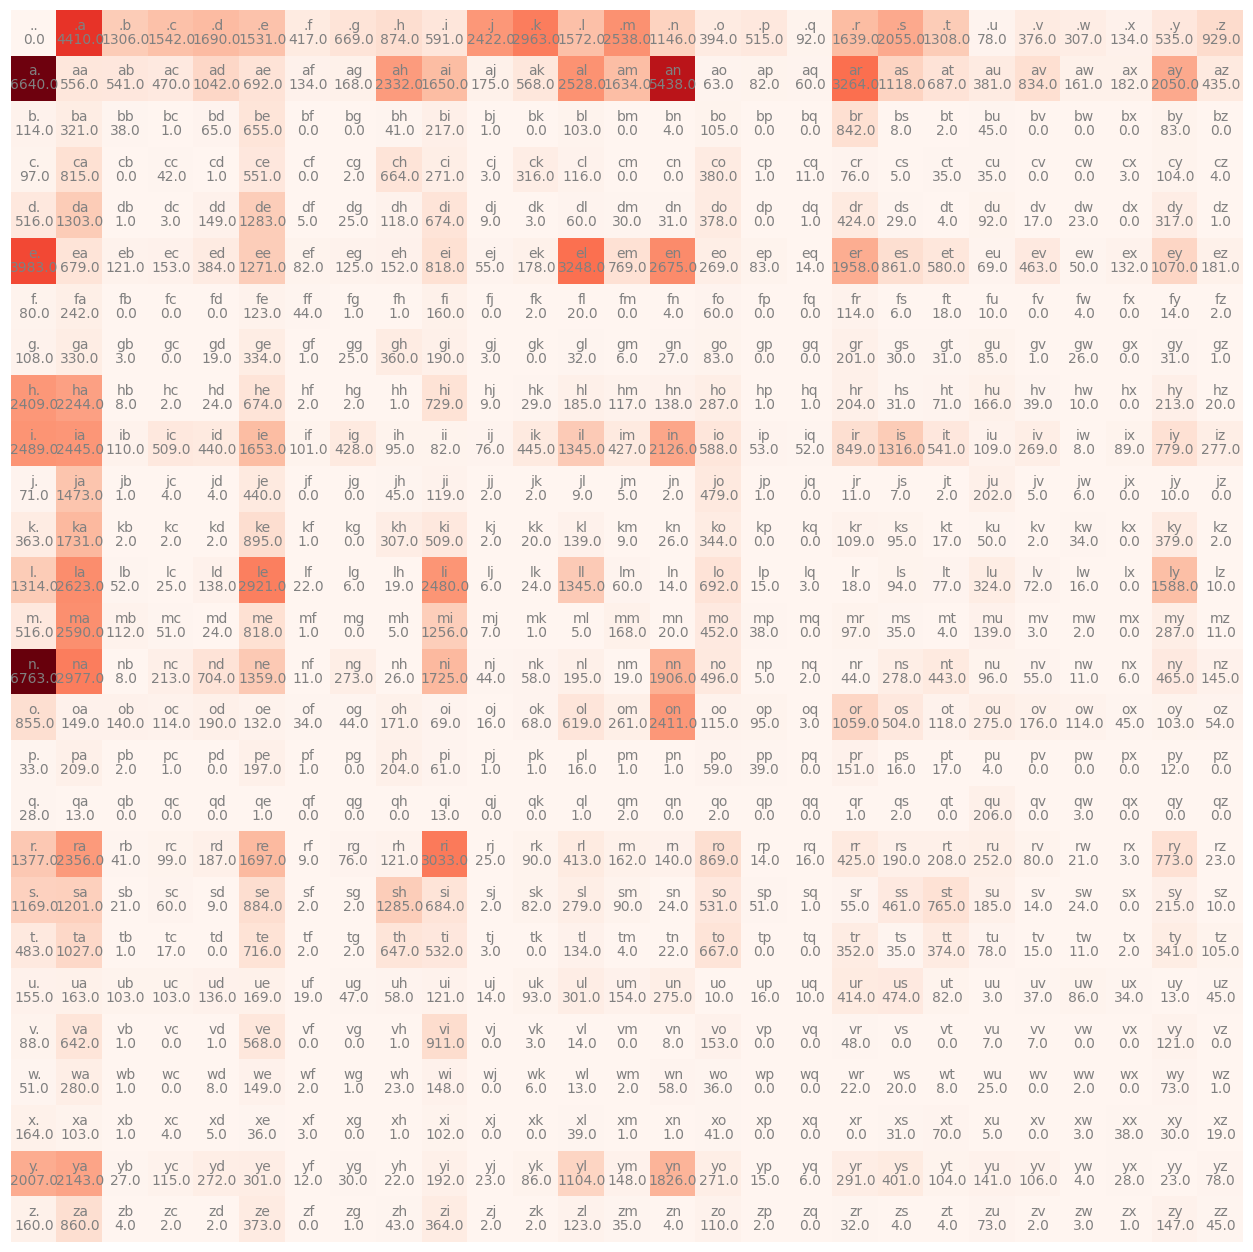

In [66]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Reds')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


In [67]:
P=(N+1).float()
P/=P.sum(1,keepdims=True)

In [68]:
g = torch.Generator().manual_seed(123456789)
for i in range(5):
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

r.
alarie.
leithari.
a.
mirocor.


# Bigram by Neural Network

In [69]:
xs=[]
ys=[]
for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs[:],chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])
xs=torch.tensor(xs)
ys=torch.tensor(ys)

In [70]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
w=torch.randn((27,27),requires_grad=True)

In [84]:
for x in range(100):

    #forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logit=xenc.matmul(w)
    counts=logit.exp()
    P=counts/counts.sum(1,keepdims=True)
    loss=-P[torch.arange(xs.nelement()), ys].log().mean() + 0.01*(w**2).mean()
    
    #backward pass
    w.grad=None
    loss.backward()

    #updation
    w.data += -1 * w.grad
print(loss.item())


2.609987258911133


In [86]:
g = torch.Generator().manual_seed(123456789)
for i in range(5):
  out = []
  ix = 0
  while True:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logit=xenc.matmul(w)
    counts=logit.exp()
    P=counts/counts.sum(1,keepdims=True)

    ix = torch.multinomial(P, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

r.
alarie.
qwitharika.
marocor.
miheynamn.
